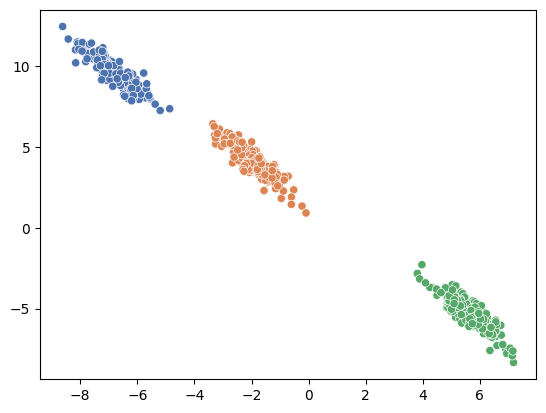

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture as SklearnGMM
from sklearn.metrics import adjusted_rand_score

from gmm import GaussianMixture

X, y_true = make_blobs(n_samples=600, centers=3, cluster_std=1.0, random_state=7)
transformation = np.array([[0.6, -0.6], [-0.3, 0.8]])
X = X @ transformation

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_true, palette="deep", legend=False)
plt.show()

In [7]:
def plot_gmm_ellipses(X, labels, means, covariances, title, n_std=2.0):
    ax = plt.gca()
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="deep", legend=False, ax=ax)

    for mean, cov in zip(means, covariances):
        eigvals, eigvecs = np.linalg.eigh(cov)
        order = eigvals.argsort()[::-1]
        eigvals, eigvecs = eigvals[order], eigvecs[:, order]
        angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
        width, height = 2 * n_std * np.sqrt(eigvals)
        ellipse = Ellipse(mean, width, height, angle=angle, facecolor="none",
                           edgecolor="black", linewidth=2, zorder=5)
        ax.add_patch(ellipse)
        ax.scatter(*mean, marker="x", color="black", s=100, linewidths=2, zorder=5)

    ax.set_title(title)
    plt.show()

# Scikit Implementation

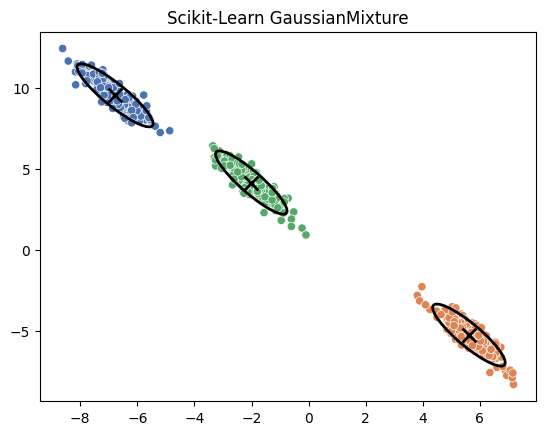

In [8]:
sk_model = SklearnGMM(n_components=3, random_state=42)
sk_model.fit(X)
sk_labels = sk_model.predict(X)

plot_gmm_ellipses(X, sk_labels, sk_model.means_, sk_model.covariances_,
                   "Scikit-Learn GaussianMixture")

# My GaussianMixture

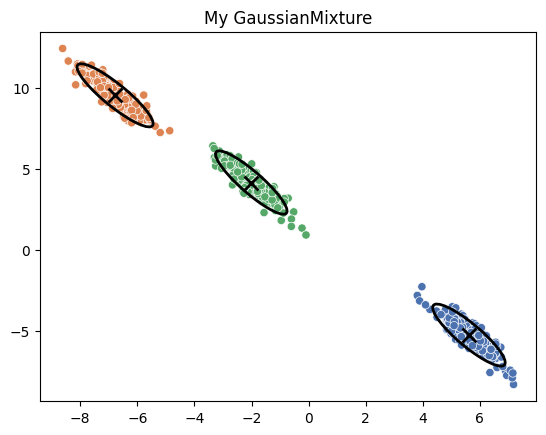

In [9]:
model = GaussianMixture(n_components=3, random_state=42)
model.fit(X)
labels = model.predict(X)

plot_gmm_ellipses(X, labels, model.means_, model.covariances_,
                   "My GaussianMixture")

## Convergence

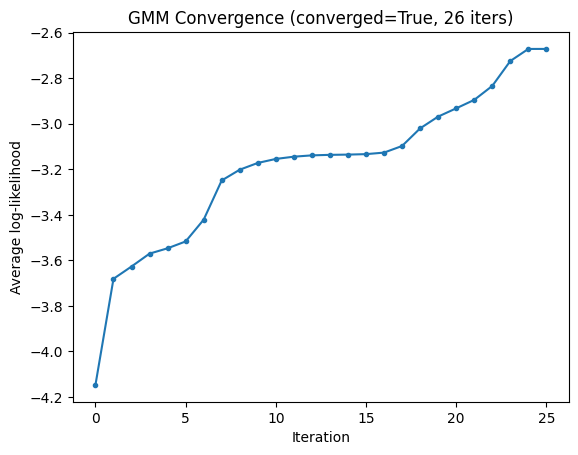

In [10]:
plt.plot(model.log_history_, marker="o", markersize=3)
plt.xlabel("Iteration")
plt.ylabel("Average log-likelihood")
plt.title(f"GMM Convergence (converged={model.converged_}, {len(model.log_history_)} iters)")
plt.show()

## Comparing Fit Quality

In [6]:
ari = adjusted_rand_score(sk_labels, labels)
print(f"Adjusted Rand Index (mine vs sklearn labels): {ari:.3f}")
print(f"Adjusted Rand Index (mine vs ground truth):   {adjusted_rand_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index (sklearn vs ground truth): {adjusted_rand_score(y_true, sk_labels):.3f}")
print()
print(f"My final avg log-likelihood:      {model.log_history_[-1]:.4f}")
print(f"Sklearn final avg log-likelihood: {sk_model.score(X):.4f}")
print()
print("My weights:     ", np.round(model.weights_, 4))
print("Sklearn weights:", np.round(sk_model.weights_, 4))

Adjusted Rand Index (mine vs sklearn labels): 1.000
Adjusted Rand Index (mine vs ground truth):   1.000
Adjusted Rand Index (sklearn vs ground truth): 1.000

My final avg log-likelihood:      -2.6712
Sklearn final avg log-likelihood: -2.6712

My weights:      [0.3333 0.3333 0.3333]
Sklearn weights: [0.3333 0.3333 0.3333]
